In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('healthcare.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [69]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

<BarContainer object of 12 artists>

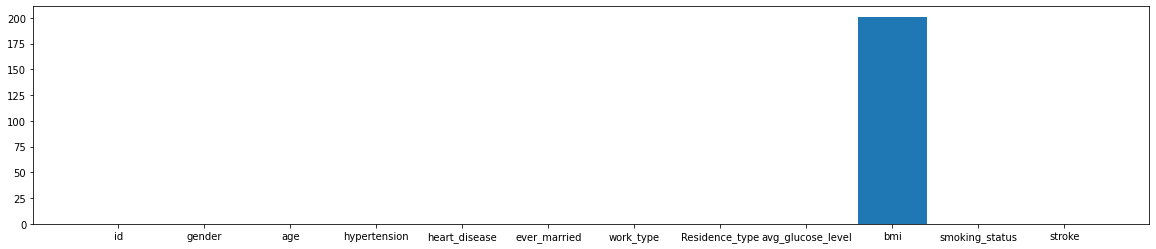

In [77]:
plt.figure(figsize=(20, 4))
plt.bar(df.columns, df.isnull().sum())

In [4]:
df3 = df.fillna(df.bmi.mean())
df3.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

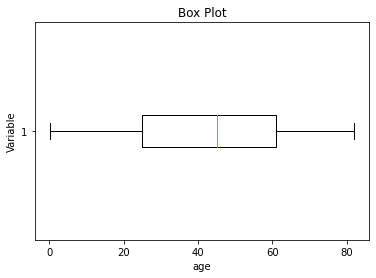

In [5]:
import matplotlib.pyplot as plt

plt.boxplot(df3['age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('age')
plt.title('Box Plot')
plt.show()

In [6]:
# calculate summary statistics
mean = df3['age'].mean()
std  = df3['age'].std()

# Calculate the lower and upper bounds
lower_bound = mean - std*2
upper_bound = mean + std*2

print('Lower Bound :',lower_bound)
print('Upper Bound :',upper_bound)

# Drop the outliers
df4 = df3[(df3['age'] >= lower_bound)
                & (df3['age'] <= upper_bound)]

Lower Bound : -1.9986789648180263
Upper Bound : 88.45190792763606


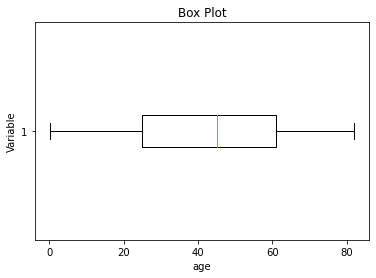

In [7]:
plt.boxplot(df4['age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('age')
plt.title('Box Plot')
plt.show()

In [8]:
df4 = df4.drop_duplicates()

In [9]:
#using label encoder for columns: gender
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df4['gender_enc'] = encoder.fit_transform(df4['gender'])
df4.drop('gender', axis=1, inplace=True)

In [10]:
df4['ever_married_enc'] = encoder.fit_transform(df4['ever_married'])
df4.drop('ever_married', axis=1, inplace=True)

In [11]:
df4['Residence_type_enc'] = encoder.fit_transform(df4['Residence_type'])
df4.drop('Residence_type', axis=1, inplace=True)

In [12]:
df4.head()

,id,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi,smoking_status,stroke,gender_enc,ever_married_enc,Residence_type_enc
0,9046,67.0,0,1,Private,228.69,36.600000,formerly smoked,1,1,1,1
1,51676,61.0,0,0,Self-employed,202.21,28.893237,never smoked,1,0,1,0
2,31112,80.0,0,1,Private,105.92,32.500000,never smoked,1,1,1,0
3,60182,49.0,0,0,Private,171.23,34.400000,smokes,1,0,1,1
4,1665,79.0,1,0,Self-employed,174.12,24.000000,never smoked,1,0,1,0


In [13]:
df4['smoking_status'].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [14]:
df4 = pd.get_dummies(df4, columns=['smoking_status'],dtype=int)


In [15]:
df4.drop('id', axis=1, inplace=True)

In [16]:
df4.head()

,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi,stroke,gender_enc,ever_married_enc,Residence_type_enc,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,Private,228.69,36.600000,1,1,1,1,0,1,0,0
1,61.0,0,0,Self-employed,202.21,28.893237,1,0,1,0,0,0,1,0
2,80.0,0,1,Private,105.92,32.500000,1,1,1,0,0,0,1,0
3,49.0,0,0,Private,171.23,34.400000,1,0,1,1,0,0,0,1
4,79.0,1,0,Self-employed,174.12,24.000000,1,0,1,0,0,0,1,0


In [17]:
df4.drop('work_type', axis=1, inplace=True)

In [18]:
df4.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_enc,ever_married_enc,Residence_type_enc,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,1,1,1,0,1,0,0
1,61.0,0,0,202.21,28.893237,1,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.500000,1,1,1,0,0,0,1,0
3,49.0,0,0,171.23,34.400000,1,0,1,1,0,0,0,1
4,79.0,1,0,174.12,24.000000,1,0,1,0,0,0,1,0


In [19]:
from sklearn.preprocessing import MinMaxScaler

df5 = pd.DataFrame()
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df4)
df5 = pd.DataFrame(scaled_array, columns=df4.columns)
df5.head(3)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_enc,ever_married_enc,Residence_type_enc,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0.816895,0.0,1.0,0.801265,0.301260,1.0,0.5,1.0,1.0,0.0,1.0,0.0,0.0
1,0.743652,0.0,0.0,0.679023,0.212981,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.975586,0.0,1.0,0.234512,0.254296,1.0,0.5,1.0,0.0,0.0,0.0,1.0,0.0


In [81]:
# correlation between column 1 and column2
print(df5['gender_enc'].corr(df5['stroke']))

0.008928866288788945


In [83]:
correlation_matrix = df5.corr()

<AxesSubplot:>

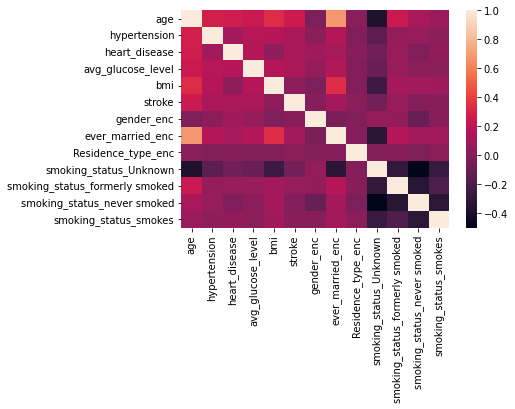

In [84]:
import seaborn as sns

sns.heatmap(correlation_matrix)

In [20]:
df5.to_csv('cleaned_data.csv', index=False)

In [21]:
X = df5.loc[:, df5.columns != 'stroke']
Y = df5['stroke']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)

In [23]:
from sklearn.metrics import classification_report,\
    confusion_matrix
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [24]:
 # Predictions and Evaluations
# Let's evaluate our KNN model !
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[946  37]
 [ 35   4]]
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       983
         1.0       0.10      0.10      0.10        39

    accuracy                           0.93      1022
   macro avg       0.53      0.53      0.53      1022
weighted avg       0.93      0.93      0.93      1022



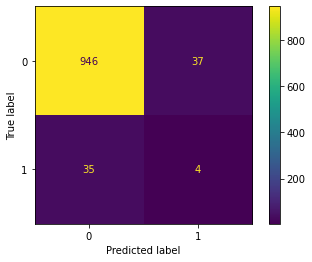

In [25]:
from sklearn import metrics

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, pred), display_labels = [0, 1])

cm_display.plot()
plt.show()

In [26]:
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train, y_train)
pred2 = knn2.predict(X_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [27]:
print(confusion_matrix(y_test, pred2))
print(classification_report(y_test, pred2))

[[970  13]
 [ 34   5]]
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       983
         1.0       0.28      0.13      0.18        39

    accuracy                           0.95      1022
   macro avg       0.62      0.56      0.58      1022
weighted avg       0.94      0.95      0.95      1022



C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to 

C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to 

Text(0, 0.5, 'Error (misclassification) Rate')

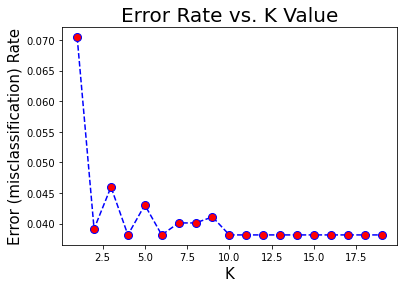

In [28]:
error_rate = []
# Will take some time
for i in range(1,20):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))


plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value', fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('Error (misclassification) Rate',fontsize=15)

In [30]:
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

Minimum error:- 0.03816046966731898 at K = 3


In [31]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [32]:
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[970  13]
 [ 34   5]]
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       983
         1.0       0.28      0.13      0.18        39

    accuracy                           0.95      1022
   macro avg       0.62      0.56      0.58      1022
weighted avg       0.94      0.95      0.95      1022



In [42]:
df5['stroke'] = df5['stroke'].astype(int)

In [52]:
df5['stroke'].loc[df5["stroke"] == 1].value_counts()

1    249
Name: stroke, dtype: int64

In [54]:
df5['stroke'].loc[df5["stroke"] == 0].value_counts()

0    4861
Name: stroke, dtype: int64

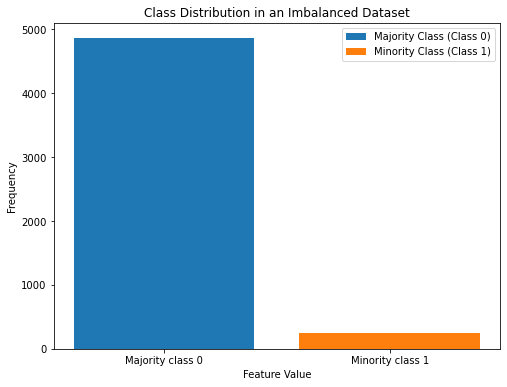

In [96]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.bar("Majority class 0", df5['stroke'].loc[df5["stroke"] == 0].value_counts(), label='Majority Class (Class 0)')
plt.bar("Minority class 1", df5['stroke'].loc[df5["stroke"] == 1].value_counts(), label='Minority Class (Class 1)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Class Distribution in an Imbalanced Dataset')
plt.legend()
plt.show()

In [98]:
# Importing imblearn library for over-sampling
from imblearn.over_sampling import RandomOverSampler

# Applying random over-sampling
over_sampler = RandomOverSampler(random_state=42)

X_over, y_over = over_sampler.fit_resample(X, Y)

In [108]:
df_over = X_over
df_over['stroke'] = y_over

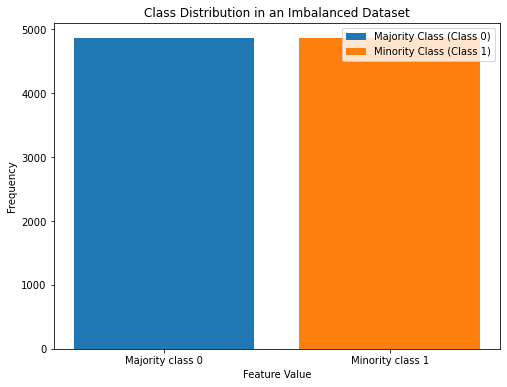

In [109]:
plt.figure(figsize=(8, 6))
plt.bar("Majority class 0", df_over['stroke'].loc[df_over["stroke"] == 0].value_counts(), label='Majority Class (Class 0)')
plt.bar("Minority class 1", df_over['stroke'].loc[df_over["stroke"] == 1].value_counts(), label='Minority Class (Class 1)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Class Distribution in an Imbalanced Dataset')
plt.legend()
plt.show()

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X_over, y_over, test_size = 0.2)

In [101]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[926  75]
 [  0 944]]
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96      1001
         1.0       0.93      1.00      0.96       944

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945



C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [102]:
# Importing imblearn, scikit-learn library
from imblearn.over_sampling import SMOTE

# For oversampling of minority class
smote = SMOTE()

# Fit predictor (x variable)
# and target (y variable) using fit_resample()
X_OverSmote, Y_OverSmote = smote.fit_resample(X, Y)


In [103]:
X_train, X_test, y_train, y_test = train_test_split(X_OverSmote, Y_OverSmote, test_size = 0.2)

In [104]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[799 134]
 [ 41 971]]
              precision    recall  f1-score   support

         0.0       0.95      0.86      0.90       933
         1.0       0.88      0.96      0.92      1012

    accuracy                           0.91      1945
   macro avg       0.91      0.91      0.91      1945
weighted avg       0.91      0.91      0.91      1945



C:\Users\HP\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
